In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

%matplotlib inline

## 1. House Price Prediction
**Context:** Predict house prices based on house size (simulated data).
X: house_size (sq. ft.) | Y: price ($)

**Tasks:**
- Generate synthetic data: 100 samples with house_size (1,000–5,000 sq. ft.) and price ($100k–$500k).
- Fit a linear regression model.
- Predict the price for a 3,200 sq. ft. house.

**Questions:**
- What is the slope? Interpret it in context.
- What price does the model predict for a 0 sq. ft. lot? Is this realistic?

Slope (house_size): 87.70
Intercept: 56600.79
Predicted price for 3200 sq.ft: $337,244.42
Predicted price for 0 sq.ft: $56,600.79 -> غير واقعي, مفيش بيت مساحته صفر, ده مجرد extrapolation رياضي مش قيمة فعلية.


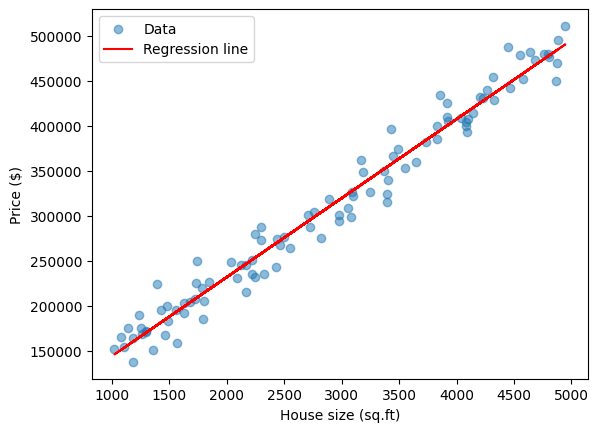

In [2]:
np.random.seed(42)
house_size = np.random.uniform(1000, 5000, 100).reshape(-1, 1)
price = 50000 + 90 * house_size.flatten() + np.random.normal(0, 20000, 100)

model_1 = LinearRegression()
model_1.fit(house_size, price)

pred_3200 = model_1.predict([[3200]])[0]

print(f"Slope (house_size): {model_1.coef_[0]:.2f}")
print(f"Intercept: {model_1.intercept_:.2f}")
print(f"Predicted price for 3200 sq.ft: ${pred_3200:,.2f}")
print(f"Predicted price for 0 sq.ft: ${model_1.intercept_:,.2f} -> غير واقعي, "
      f"مفيش بيت مساحته صفر, ده مجرد extrapolation رياضي مش قيمة فعلية.")

plt.scatter(house_size, price, alpha=0.5, label="Data")
plt.plot(house_size, model_1.predict(house_size), color="red", label="Regression line")
plt.xlabel("House size (sq.ft)"); plt.ylabel("Price ($)"); plt.legend(); plt.show()

## 2. Exam Scores vs. Study Hours
**Context:** Explore the relationship between study time and exam scores.
X: study_hours (hours/day) | Y: exam_score (0–100)

**Tasks:**
- Create data: 50 samples with study_hours (1–10) and exam_score (50–100).
- Split data (80% train, 20% test).
- Train the model and evaluate using MSE.

```python
np.random.seed(42)
study_hours = np.random.uniform(1, 10, 50).reshape(-1, 1)
exam_score = 50 + 5*study_hours + np.random.normal(0, 8, 50).reshape(-1, 1)
```

**Questions:**
- How much does the score increase per additional study hour?
- What score is predicted for 5 hours of study?

Slope (score per extra study hour): 4.75
MSE on test set: 50.96
Predicted score for 5 study hours: 75.01


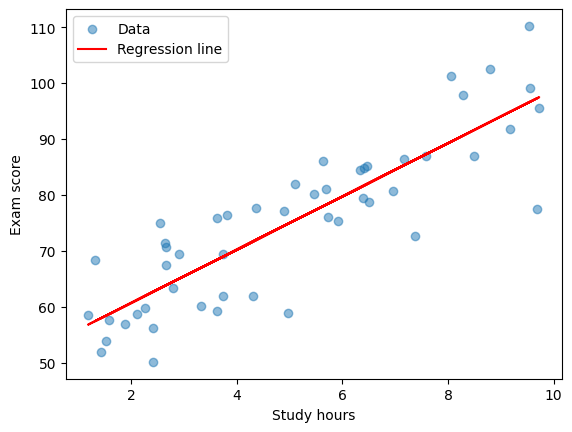

In [3]:
np.random.seed(42)
study_hours = np.random.uniform(1, 10, 50).reshape(-1, 1)
exam_score = 50 + 5 * study_hours + np.random.normal(0, 8, 50).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    study_hours, exam_score, test_size=0.2, random_state=42
)

model_2 = LinearRegression()
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)
mse_2 = mean_squared_error(y_test, y_pred_2)

pred_5h = model_2.predict([[5]])[0][0]

print(f"Slope (score per extra study hour): {model_2.coef_[0][0]:.2f}")
print(f"MSE on test set: {mse_2:.2f}")
print(f"Predicted score for 5 study hours: {pred_5h:.2f}")

plt.scatter(study_hours, exam_score, alpha=0.5, label="Data")
plt.plot(study_hours, model_2.predict(study_hours), color="red", label="Regression line")
plt.xlabel("Study hours"); plt.ylabel("Exam score"); plt.legend(); plt.show()

## 3. Diabetes Progression Prediction
**Context:** Predict disease progression using BMI (built-in dataset).
X: BMI (bmi, scaled) | Y: Disease progression (target)

**Tasks:**
- Load the diabetes dataset: `load_diabetes()`.
- Use only the bmi feature.
- Plot data and regression line.

**Questions:**
- What is the R² score? Is the model useful?
- How does progression change for a BMI increase of 1 unit?

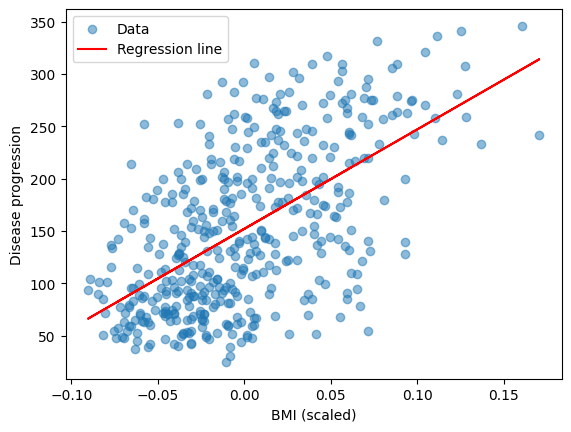

R^2 score: 0.344
تفسير: R^2 حوالي 0.34 يعني BMI لوحده بيفسر جزء بسيط من التباين في تطور المرض، فهو مؤشر مفيد لكن مش كافي لوحده كنموذج تنبؤي قوي.
Slope (per 1 unit BMI increase): 949.44 (الـ BMI هنا scaled مش القيمة الحقيقية, فالتفسير نسبي مش بوحدات BMI فعلية)


In [4]:
diabetes = load_diabetes()
bmi = diabetes.data[:, diabetes.feature_names.index("bmi")].reshape(-1, 1)
target = diabetes.target

model_3 = LinearRegression()
model_3.fit(bmi, target)
r2_3 = r2_score(target, model_3.predict(bmi))

plt.scatter(bmi, target, alpha=0.5, label="Data")
plt.plot(bmi, model_3.predict(bmi), color="red", label="Regression line")
plt.xlabel("BMI (scaled)"); plt.ylabel("Disease progression"); plt.legend(); plt.show()

print(f"R^2 score: {r2_3:.3f}")
print("تفسير: R^2 حوالي 0.34 يعني BMI لوحده بيفسر جزء بسيط من التباين "
      "في تطور المرض، فهو مؤشر مفيد لكن مش كافي لوحده كنموذج تنبؤي قوي.")
print(f"Slope (per 1 unit BMI increase): {model_3.coef_[0]:.2f} "
      "(الـ BMI هنا scaled مش القيمة الحقيقية, فالتفسير نسبي مش بوحدات BMI فعلية)")

## 4. Temperature vs. Ice Cream Sales
**Context:** Model ice cream sales based on temperature.
X: temperature (°C) | Y: sales (units sold)

**Tasks:**
- Generate data: Temperature (15°C–35°C), sales (50–200 units).
- Fit the model and calculate MSE.
- Predict sales at 25°C.

```python
np.random.seed(42)
temperature = np.random.uniform(15, 35, 50).reshape(-1, 1)
sales = 20 + 5*temperature + np.random.normal(0, 10, 50).reshape(-1, 1)
```

**Questions:**
- Is the intercept meaningful here? Why?
- What sales are predicted at 0°C? Is this reasonable?

MSE: 82.31
Predicted sales at 25°C: 144.85 units
Predicted sales at 0°C: 22.64 units -> الـ intercept هنا مش ذو معنى حقيقي كامل لأن البيانات الأصلية كانت بين 15° و35° فقط, فالتنبؤ عند 0° ده extrapolation برة نطاق البيانات.


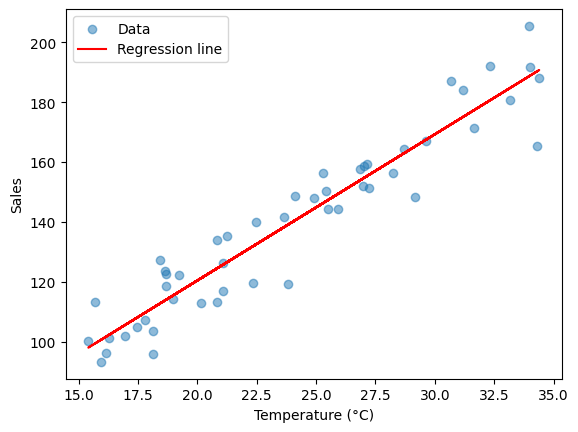

In [5]:
np.random.seed(42)
temperature = np.random.uniform(15, 35, 50).reshape(-1, 1)
sales_4 = 20 + 5 * temperature + np.random.normal(0, 10, 50).reshape(-1, 1)

model_4 = LinearRegression()
model_4.fit(temperature, sales_4)
mse_4 = mean_squared_error(sales_4, model_4.predict(temperature))
pred_25c = model_4.predict([[25]])[0][0]
pred_0c = model_4.predict([[0]])[0][0]

print(f"MSE: {mse_4:.2f}")
print(f"Predicted sales at 25°C: {pred_25c:.2f} units")
print(f"Predicted sales at 0°C: {pred_0c:.2f} units -> "
      "الـ intercept هنا مش ذو معنى حقيقي كامل لأن البيانات الأصلية "
      "كانت بين 15° و35° فقط, فالتنبؤ عند 0° ده extrapolation برة نطاق البيانات.")

plt.scatter(temperature, sales_4, alpha=0.5, label="Data")
plt.plot(temperature, model_4.predict(temperature), color="red", label="Regression line")
plt.xlabel("Temperature (°C)"); plt.ylabel("Sales"); plt.legend(); plt.show()

## 5. Employee Salary vs. Experience
**Context:** Predict salary based on years of experience.
X: experience (years) | Y: salary ($1,000s)

**Tasks:**
- Create data: Experience (0–20 years), salary (40–200k).
- Split data (70% train, 30% test).
- Evaluate using R².

```python
np.random.seed(42)
experience = np.random.uniform(0, 20, 100).reshape(-1, 1)
salary = 40 + 8*experience + np.random.normal(0, 10, 100).reshape(-1, 1)
```

**Questions:**
- What salary is predicted for 15 years of experience?
- What percentage of salary variation is explained by experience?

Predicted salary for 15 years experience: $157.68k
R^2 on test set: 0.977 -> يعني حوالي 97.7% من التباين في المرتب بيتفسر بسنوات الخبرة.


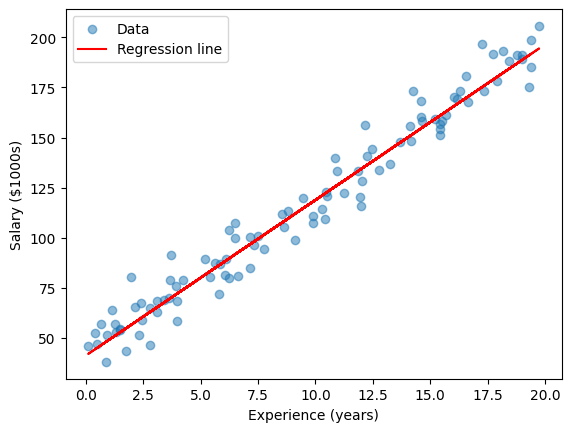

In [6]:
np.random.seed(42)
experience = np.random.uniform(0, 20, 100).reshape(-1, 1)
salary = 40 + 8 * experience + np.random.normal(0, 10, 100).reshape(-1, 1)

X_train5, X_test5, y_train5, y_test5 = train_test_split(
    experience, salary, test_size=0.3, random_state=42
)

model_5 = LinearRegression()
model_5.fit(X_train5, y_train5)
r2_5 = r2_score(y_test5, model_5.predict(X_test5))
pred_15y = model_5.predict([[15]])[0][0]

print(f"Predicted salary for 15 years experience: ${pred_15y:.2f}k")
print(f"R^2 on test set: {r2_5:.3f} -> يعني حوالي {r2_5*100:.1f}% من "
      "التباين في المرتب بيتفسر بسنوات الخبرة.")

plt.scatter(experience, salary, alpha=0.5, label="Data")
plt.plot(experience, model_5.predict(experience), color="red", label="Regression line")
plt.xlabel("Experience (years)"); plt.ylabel("Salary ($1000s)"); plt.legend(); plt.show()

## 6. Car Fuel Efficiency
**Context:** Model MPG based on engine displacement.
X: displacement (L) | Y: mpg (miles/gallon)

**Tasks:**
- Use the mtcars dataset (load via URL).
- Plot displacement vs. MPG with regression line.

```python
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
data = pd.read_csv(url)
```

**Questions:**
- Interpret the slope. Is higher displacement linked to better/worse MPG?
- What MPG is predicted for a 4.0L engine?

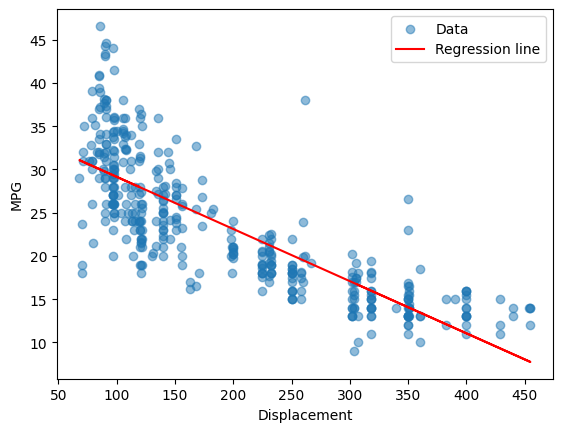

Slope: -0.0603
التفسير: الميل سالب, يعني كل ما زاد الـ displacement (سعة المحرك) كل ما قلت الـ MPG -> علاقة عكسية (محرك أكبر = استهلاك بنزين أكتر).
Predicted MPG for displacement=4.0: 34.93


In [7]:
try:
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
    data_6 = pd.read_csv(url)
    data_6 = data_6.dropna(subset=["displacement", "mpg"])
    disp = data_6["displacement"].values.reshape(-1, 1)
    mpg = data_6["mpg"].values

    model_6 = LinearRegression()
    model_6.fit(disp, mpg)
    pred_4L = model_6.predict([[4.0]])[0]

    plt.scatter(disp, mpg, alpha=0.5, label="Data")
    plt.plot(disp, model_6.predict(disp), color="red", label="Regression line")
    plt.xlabel("Displacement"); plt.ylabel("MPG"); plt.legend(); plt.show()

    print(f"Slope: {model_6.coef_[0]:.4f}")
    print("التفسير: الميل سالب, يعني كل ما زاد الـ displacement (سعة المحرك) "
          "كل ما قلت الـ MPG -> علاقة عكسية (محرك أكبر = استهلاك بنزين أكتر).")
    print(f"Predicted MPG for displacement=4.0: {pred_4L:.2f}")
except Exception as e:
    print(f"تعذر تحميل الداتاست من الإنترنت -> {e}")

## 7. Product Price vs. Demand
**Context:** Analyze how price affects demand.
X: price ($) | Y: demand (units sold)

**Tasks:**
- Generate data: Price ($10–$50), demand (200–20 units).
- Fit the model and calculate residuals.

```python
np.random.seed(42)
price = np.random.uniform(10, 50, 50).reshape(-1, 1)
demand = 300 - 6*price + np.random.normal(0, 15, 50).reshape(-1, 1)
```

**Questions:**
- Why is the slope negative?
- What demand is predicted at $35?

Slope: -6.08 -> سالب لأن العلاقة بين السعر والطلب عكسية بطبيعتها: كل ما زاد السعر, كل ما قل عدد الوحدات المطلوبة (قانون الطلب في الاقتصاد).
Predicted demand at price=$35: 89.36 units
Residuals sample (first 5): [ 10.88193451   4.30651355  -0.73177838  -3.96048469 -23.10527095]


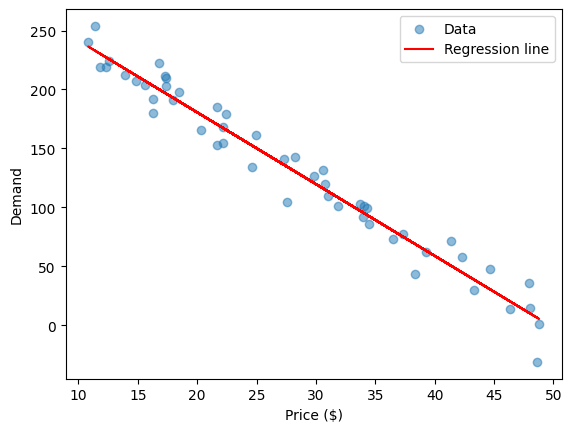

In [8]:
np.random.seed(42)
price_7 = np.random.uniform(10, 50, 50).reshape(-1, 1)
demand = 300 - 6 * price_7 + np.random.normal(0, 15, 50).reshape(-1, 1)

model_7 = LinearRegression()
model_7.fit(price_7, demand)
residuals_7 = demand - model_7.predict(price_7)
pred_35 = model_7.predict([[35]])[0][0]

print(f"Slope: {model_7.coef_[0][0]:.2f} -> سالب لأن العلاقة بين السعر والطلب "
      "عكسية بطبيعتها: كل ما زاد السعر, كل ما قل عدد الوحدات المطلوبة (قانون الطلب في الاقتصاد).")
print(f"Predicted demand at price=$35: {pred_35:.2f} units")
print(f"Residuals sample (first 5): {residuals_7[:5].flatten()}")

plt.scatter(price_7, demand, alpha=0.5, label="Data")
plt.plot(price_7, model_7.predict(price_7), color="red", label="Regression line")
plt.xlabel("Price ($)"); plt.ylabel("Demand"); plt.legend(); plt.show()

## 8. Student Height vs. Weight
**Context:** Predict weight using height.
X: height (cm) | Y: weight (kg)

**Tasks:**
- Create synthetic data: Height (150–200 cm), weight (45–100 kg).
- Train the model and compute MSE.

```python
np.random.seed(42)
height = np.random.uniform(150, 200, 100).reshape(-1, 1)
weight = 0.8*height - 70 + np.random.normal(0, 5, 100).reshape(-1, 1)
```

**Questions:**
- What weight is predicted for 175 cm?
- Why is the intercept not zero?

MSE: 20.16
Predicted weight for 175 cm: 69.93 kg
الـ intercept مش صفر لأن العلاقة الخطية بين الطول والوزن مش بتعدي من نقطة الأصل (0,0) - مفيش إنسان طوله صفر ووزنه صفر, فالـ intercept هنا مجرد قيمة رياضية تظبط الخط مش قيمة لها معنى فيزيائي مباشر.


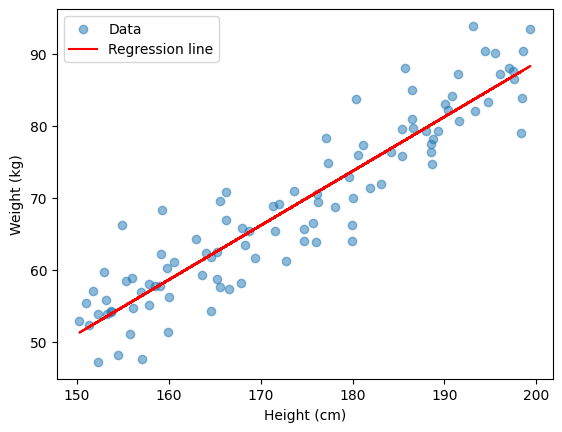

In [9]:
np.random.seed(42)
height = np.random.uniform(150, 200, 100).reshape(-1, 1)
weight = 0.8 * height - 70 + np.random.normal(0, 5, 100).reshape(-1, 1)

model_8 = LinearRegression()
model_8.fit(height, weight)
mse_8 = mean_squared_error(weight, model_8.predict(height))
pred_175 = model_8.predict([[175]])[0][0]

print(f"MSE: {mse_8:.2f}")
print(f"Predicted weight for 175 cm: {pred_175:.2f} kg")
print("الـ intercept مش صفر لأن العلاقة الخطية بين الطول والوزن مش بتعدي من نقطة "
      "الأصل (0,0) - مفيش إنسان طوله صفر ووزنه صفر, فالـ intercept هنا مجرد قيمة "
      "رياضية تظبط الخط مش قيمة لها معنى فيزيائي مباشر.")

plt.scatter(height, weight, alpha=0.5, label="Data")
plt.plot(height, model_8.predict(height), color="red", label="Regression line")
plt.xlabel("Height (cm)"); plt.ylabel("Weight (kg)"); plt.legend(); plt.show()

## 9. Advertising Spend vs. Sales
**Context:** Model sales based on TV ad spending.
X: tv_ad_budget ($1,000s) | Y: sales (units)

**Tasks:**
- Generate data: TV budget (1–100k), sales (100–1,000 units).
- Split data (75% train, 25% test).

```python
np.random.seed(42)
tv_budget = np.random.uniform(1, 100, 100).reshape(-1, 1)
sales = 50 + 8*tv_budget + np.random.normal(0, 30, 100).reshape(-1, 1)
```

**Questions:**
- How much do sales increase per $1k spent on TV ads?
- What sales are predicted with a $80k budget?

Slope (sales increase per $1k): 7.83 units
Predicted sales with $80k budget: 681.94 units


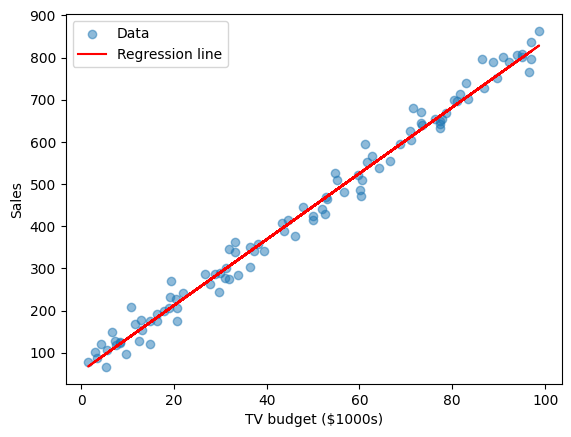

In [10]:
np.random.seed(42)
tv_budget = np.random.uniform(1, 100, 100).reshape(-1, 1)
sales_9 = 50 + 8 * tv_budget + np.random.normal(0, 30, 100).reshape(-1, 1)

X_train9, X_test9, y_train9, y_test9 = train_test_split(
    tv_budget, sales_9, test_size=0.25, random_state=42
)

model_9 = LinearRegression()
model_9.fit(X_train9, y_train9)
pred_80k = model_9.predict([[80]])[0][0]

print(f"Slope (sales increase per $1k): {model_9.coef_[0][0]:.2f} units")
print(f"Predicted sales with $80k budget: {pred_80k:.2f} units")

plt.scatter(tv_budget, sales_9, alpha=0.5, label="Data")
plt.plot(tv_budget, model_9.predict(tv_budget), color="red", label="Regression line")
plt.xlabel("TV budget ($1000s)"); plt.ylabel("Sales"); plt.legend(); plt.show()

## 10. Crop Yield vs. Rainfall
**Context:** Predict crop yield based on rainfall.
X: rainfall (mm) | Y: crop_yield (tons/hectare)

**Tasks:**
- Generate data: Rainfall (300–900 mm), yield (2–8 tons).
- Plot residuals and check patterns.

```python
np.random.seed(42)
rainfall = np.random.uniform(300, 900, 50).reshape(-1, 1)
crop_yield = 2 + 0.007*rainfall + np.random.normal(0, 0.5, 50).reshape(-1, 1)
```

**Questions:**
- Is the relationship linear?
- What yield is expected with 600 mm of rain?

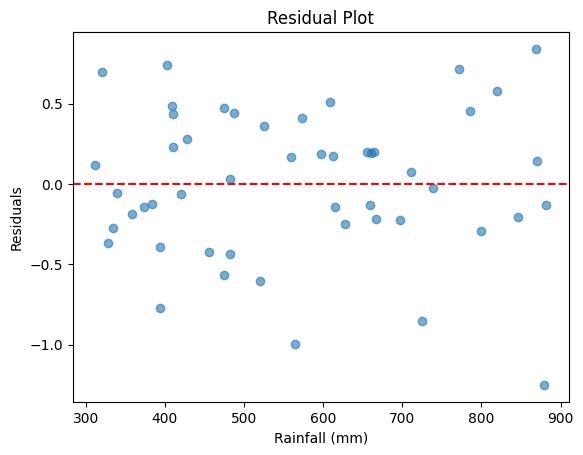

Predicted yield at 600mm rainfall: 6.19 tons/hectare
العلاقة خطية تقريبًا لأن الـ residuals متبعترة عشوائي حوالين الصفر من غير أي نمط أو شكل منحني واضح (لأن البيانات نفسها اتولدت بعلاقة خطية + نويز عشوائي).


In [11]:
np.random.seed(42)
rainfall = np.random.uniform(300, 900, 50).reshape(-1, 1)
crop_yield = 2 + 0.007 * rainfall + np.random.normal(0, 0.5, 50).reshape(-1, 1)

model_10 = LinearRegression()
model_10.fit(rainfall, crop_yield)
residuals_10 = crop_yield - model_10.predict(rainfall)
pred_600mm = model_10.predict([[600]])[0][0]

plt.scatter(rainfall, residuals_10, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Rainfall (mm)"); plt.ylabel("Residuals"); plt.title("Residual Plot"); plt.show()

print(f"Predicted yield at 600mm rainfall: {pred_600mm:.2f} tons/hectare")
print("العلاقة خطية تقريبًا لأن الـ residuals متبعترة عشوائي حوالين الصفر "
      "من غير أي نمط أو شكل منحني واضح (لأن البيانات نفسها اتولدت بعلاقة خطية + نويز عشوائي).")